In [1]:
# ============================================
# Import Libraries
# ============================================

import os
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader, random_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
# ============================================
# Reproducibility
# ============================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

In [5]:
# ============================================
# Device Configuration
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 40)
print(f"Device : {device}")

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("=" * 40)

Device : cuda
GPU : Tesla T4


In [7]:
# ============================================
# Dataset Paths
# ============================================

DATASET_PATH = Path("/kaggle/input/datasets/salmansajid05/oral-diseases")

WORKING_DIR = Path("/kaggle/working")

CLEAN_DATASET = WORKING_DIR / "dataset_clean"

SPLIT_DATASET = WORKING_DIR / "dataset"

MODEL_DIR = WORKING_DIR / "saved_models"

RESULTS_DIR = WORKING_DIR / "results"

MODEL_DIR.mkdir(exist_ok=True)

RESULTS_DIR.mkdir(exist_ok=True)

In [8]:
# ============================================
# Display Dataset Structure
# ============================================

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(str(DATASET_PATH), "").count(os.sep)

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    subindent = " " * 4 * (level + 1)

    for f in files[:5]:
        print(f"{subindent}{f}")

oral-diseases/
    Data caries/
        Data caries/
            caries orignal data set/
                done/
            caries augmented data set/
                preview/
    Mouth Ulcer/
        Mouth Ulcer/
            Mouth_Ulcer_augmented_DataSet/
                preview/
            ulcer original dataset/
                ulcer original dataset/
    Tooth Discoloration/
        Tooth Discoloration /
            Tooth_discoloration_augmented_dataser/
                preview/
            tooth discoloration original dataset/
                tooth discoloration original dataset/
    hypodontia/
        hypodontia/
    Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/
        Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/
            Data/
                labels/
                    val/
                    train/
                images/
                    val/
                    train/
    Gingivitis/
        Gingivitis/
    Calculus/
     

In [10]:
# ============================================
# Create Clean Dataset Folder
# ============================================

import os
import shutil
from pathlib import Path
from PIL import Image

# Create clean dataset folder
CLEAN_DATASET.mkdir(exist_ok=True)

SOURCE_FOLDERS = {
    "Calculus":
        DATASET_PATH / "Calculus" / "Calculus",

    "Caries":
        DATASET_PATH / "Data caries" / "Data caries" / "caries orignal data set" / "done",

    "Gingivitis":
        DATASET_PATH / "Gingivitis" / "Gingivitis",

    "Mouth_Ulcer":
        DATASET_PATH / "Mouth Ulcer" / "Mouth Ulcer" / "ulcer original dataset" / "ulcer original dataset",

    "Tooth_Discoloration":
        DATASET_PATH / "Tooth Discoloration" / "Tooth Discoloration " / "tooth discoloration original dataset" / "tooth discoloration original dataset",

    "Hypodontia":
        DATASET_PATH / "hypodontia" / "hypodontia",
}

In [11]:
print("=" * 60)

for class_name, folder in SOURCE_FOLDERS.items():
    print(f"{class_name:25} --> {folder.exists()}")

print("=" * 60)

Calculus                  --> True
Caries                    --> True
Gingivitis                --> True
Mouth_Ulcer               --> True
Tooth_Discoloration       --> True
Hypodontia                --> True


In [13]:
# ============================================
# Prepare Clean Dataset
# ============================================

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def prepare_dataset():

    total_images = 0

    for class_name, source_folder in SOURCE_FOLDERS.items():

        destination = CLEAN_DATASET / class_name
        destination.mkdir(parents=True, exist_ok=True)

        copied = 0
        skipped = 0

        for root, _, files in os.walk(source_folder):

            for file in files:

                if not file.lower().endswith(VALID_EXTENSIONS):
                    continue

                src = Path(root) / file

                try:
                    img = Image.open(src)
                    img.verify()

                    shutil.copy2(src, destination / file)
                    copied += 1

                except Exception:
                    skipped += 1

        total_images += copied

        print(f"{class_name:<22} Copied: {copied:5d}   Skipped: {skipped}")

    print("-"*50)
    print(f"Total Images : {total_images}")

In [14]:
prepare_dataset()

Calculus               Copied:  1296   Skipped: 0
Caries                 Copied:   219   Skipped: 0
Gingivitis             Copied:  2349   Skipped: 0
Mouth_Ulcer            Copied:   265   Skipped: 0
Tooth_Discoloration    Copied:   183   Skipped: 0
Hypodontia             Copied:  1251   Skipped: 0
--------------------------------------------------
Total Images : 5563


In [15]:
# ============================================
# Count Images Per Class
# ============================================

class_counts = {}

for class_name in os.listdir(CLEAN_DATASET):

    class_path = CLEAN_DATASET / class_name

    if class_path.is_dir():

        class_counts[class_name] = len(os.listdir(class_path))

df = pd.DataFrame({
    "Class": class_counts.keys(),
    "Images": class_counts.values()
})

df = df.sort_values("Images", ascending=False)

display(df)

,Class,Images
2,Gingivitis,2349
4,Calculus,1296
0,Hypodontia,1251
5,Mouth_Ulcer,265
1,Caries,219
3,Tooth_Discoloration,183


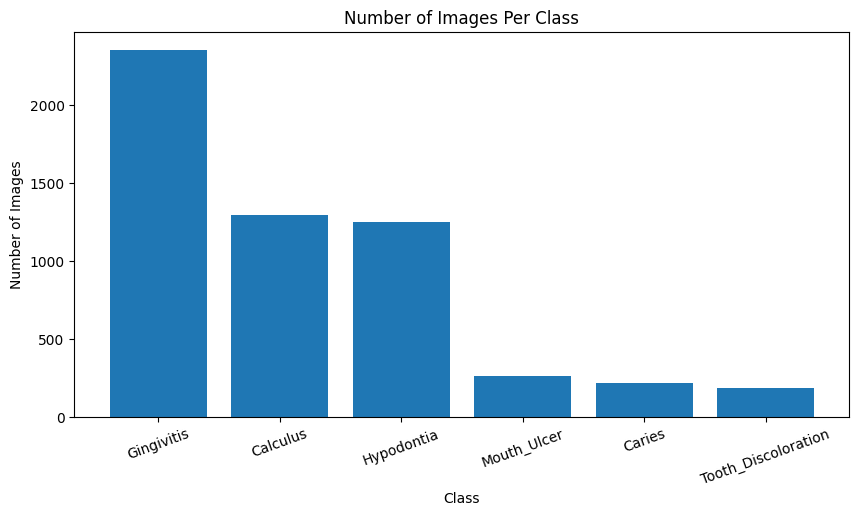

In [16]:
# ============================================
# Bar Chart
# ============================================

plt.figure(figsize=(10,5))

plt.bar(df["Class"], df["Images"])

plt.title("Number of Images Per Class")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

In [17]:
import os

for class_name in sorted(os.listdir(CLEAN_DATASET)):
    class_path = CLEAN_DATASET / class_name

    if class_path.is_dir():
        image = os.listdir(class_path)[0]
        print(class_name, "---->", image)

Calculus ----> (979).jpg
Caries ----> 114.jpg
Gingivitis ----> (2112).jpg
Hypodontia ----> (46).JPG
Mouth_Ulcer ----> 114.jpg
Tooth_Discoloration ----> 114.jpg


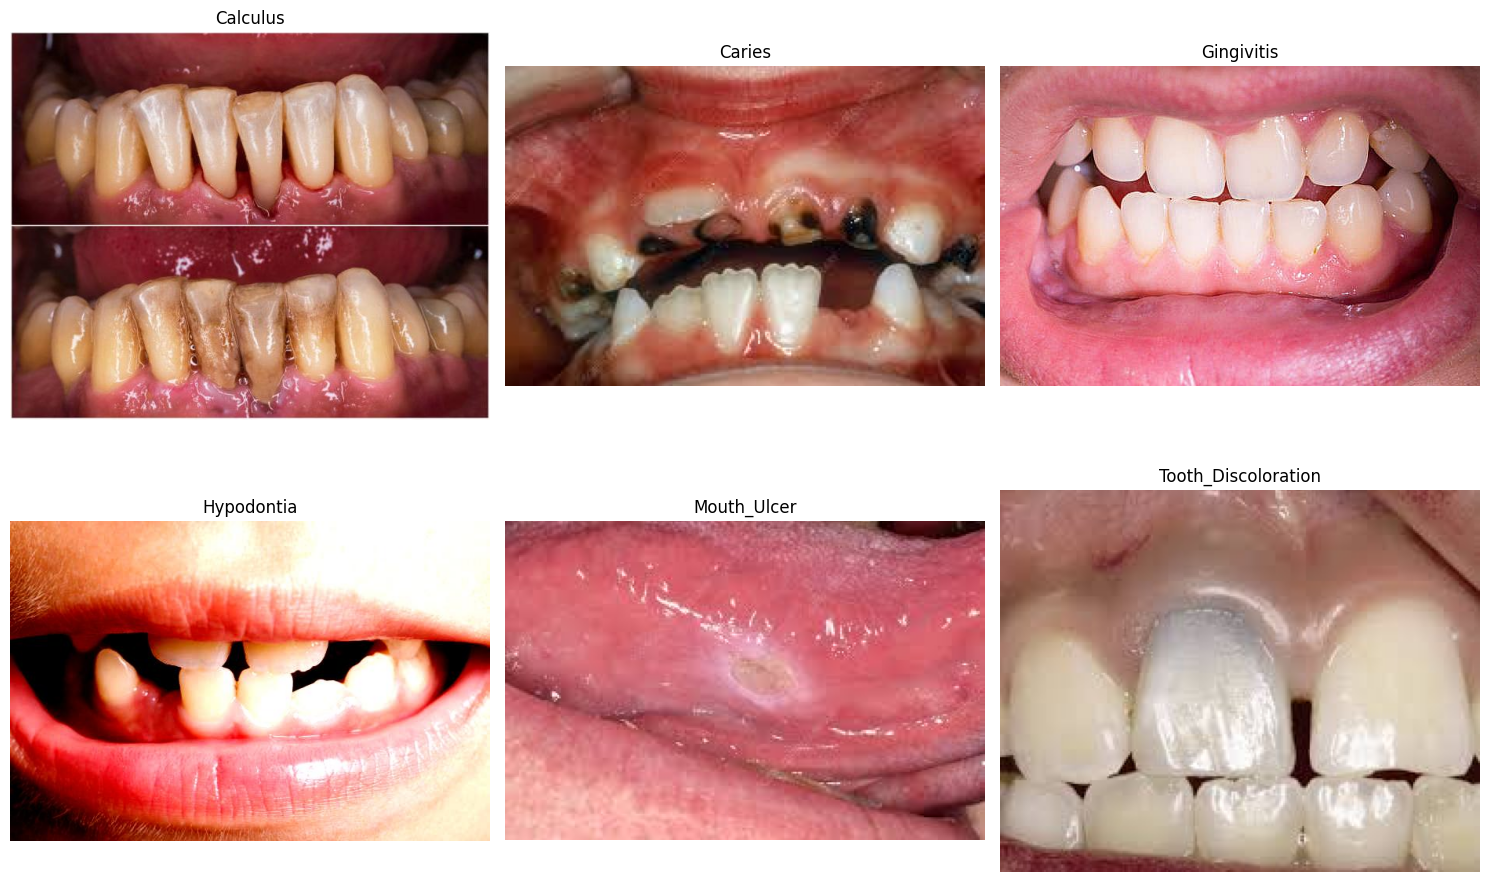

In [20]:
# ============================================
# Display Sample Images
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15,10))

axes = axes.flatten()

for idx, class_name in enumerate(sorted(os.listdir(CLEAN_DATASET))):

    class_path = CLEAN_DATASET / class_name

    image_name = random.choice(os.listdir(class_path))

    image = Image.open(class_path / image_name)

    axes[idx].imshow(image)

    axes[idx].set_title(class_name)

    axes[idx].axis("off")

plt.tight_layout()

plt.show()

In [21]:
# ============================================
# Image Size Analysis
# ============================================

widths = []

heights = []

for class_name in os.listdir(CLEAN_DATASET):

    class_path = CLEAN_DATASET / class_name

    for img_name in os.listdir(class_path):

        try:
            img = Image.open(class_path / img_name)

            w, h = img.size

            widths.append(w)

            heights.append(h)

        except:
            pass

print(f"Min Width  : {min(widths)}")
print(f"Max Width  : {max(widths)}")

print(f"Min Height : {min(heights)}")
print(f"Max Height : {max(heights)}")

print(f"Average Width  : {np.mean(widths):.1f}")
print(f"Average Height : {np.mean(heights):.1f}")

Min Width  : 121
Max Width  : 685
Min Height : 33
Max Height : 612
Average Width  : 510.8
Average Height : 320.2


# 6. Train, Validation, and Test Split

In this section, the cleaned dataset is divided into training,
validation, and testing subsets.

Stratified sampling is used to preserve the class distribution
across all subsets, ensuring a fair evaluation of the models.

In [22]:
# ============================================
# Create DataFrame of Images
# ============================================

image_paths = []
labels = []

# Iterate over each class folder
for class_name in sorted(os.listdir(CLEAN_DATASET)):

    class_folder = CLEAN_DATASET / class_name

    # Skip non-directory files
    if not class_folder.is_dir():
        continue

    # Read every image inside the class folder
    for image_name in os.listdir(class_folder):

        image_path = class_folder / image_name

        # Save image path
        image_paths.append(str(image_path))

        # Save corresponding label
        labels.append(class_name)

# Create DataFrame
df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

# Shuffle the dataset
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Display first five rows
df.head()

,image_path,label
0,/kaggle/working/dataset_clean/Calculus/(1056).jpg,Calculus
1,/kaggle/working/dataset_clean/Gingivitis/(888)...,Gingivitis
2,/kaggle/working/dataset_clean/Gingivitis/(23).jpg,Gingivitis
3,/kaggle/working/dataset_clean/Gingivitis/(1057...,Gingivitis
4,/kaggle/working/dataset_clean/Gingivitis/(2012...,Gingivitis


In [25]:
# ============================================
# Split Dataset
# ============================================

# Split into Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# Split Temp into Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print(f"Training Images   : {len(train_df)}")
print(f"Validation Images : {len(val_df)}")
print(f"Testing Images    : {len(test_df)}")

Training Images   : 3894
Validation Images : 834
Testing Images    : 835


In [26]:
# ============================================
# Check Class Distribution
# ============================================

print("Training Set")
display(train_df["label"].value_counts())

print("\nValidation Set")
display(val_df["label"].value_counts())

print("\nTesting Set")
display(test_df["label"].value_counts())

Training Set


label
Gingivitis             1644
Calculus                907
Hypodontia              876
Mouth_Ulcer             186
Caries                  153
Tooth_Discoloration     128
Name: count, dtype: int64


Validation Set


label
Gingivitis             352
Calculus               194
Hypodontia             187
Mouth_Ulcer             40
Caries                  33
Tooth_Discoloration     28
Name: count, dtype: int64


Testing Set


label
Gingivitis             353
Calculus               195
Hypodontia             188
Mouth_Ulcer             39
Caries                  33
Tooth_Discoloration     27
Name: count, dtype: int64

# 7. Data Augmentation and Image Preprocessing

Before training the models, all images are resized to a fixed size.

Data augmentation is applied only to the training set to improve
generalization and reduce overfitting.

Validation and testing images are only resized and normalized to
ensure a fair evaluation.

In [27]:
# ============================================
# Image Configuration
# ============================================

# Image size expected by pretrained models
IMAGE_SIZE = 224

# Number of classes
NUM_CLASSES = df["label"].nunique()

print(f"Image Size : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Classes    : {NUM_CLASSES}")

Image Size : 224 x 224
Classes    : 6


In [28]:
# ============================================
# Data Augmentation
# ============================================

# Mean and standard deviation of ImageNet
# Required for pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transformations
train_transform = transforms.Compose([

    # Resize image
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    # Random rotation
    transforms.RandomRotation(15),

    # Slight color changes
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize pixel values
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

])

# Validation transformations
val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

])

# Test transformations
test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

])

# 8. Custom PyTorch Dataset

A custom dataset class is implemented to load images directly
from the DataFrame.

This approach provides greater flexibility than using ImageFolder
and allows different transformations for training, validation,
and testing datasets.

In [29]:
# ============================================
# Custom Dataset
# ============================================

class OralDiseaseDataset(torch.utils.data.Dataset):
    """
    Custom Dataset for Oral Disease Classification.
    """

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe

        self.transform = transform

        # Create class-to-index mapping
        self.class_to_idx = {
            label: idx
            for idx, label in enumerate(sorted(self.dataframe["label"].unique()))
        }

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        # Get image path
        image_path = self.dataframe.iloc[index]["image_path"]

        # Get class label
        label = self.dataframe.iloc[index]["label"]

        # Open image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations
        if self.transform:

            image = self.transform(image)

        # Convert label to integer
        label = self.class_to_idx[label]

        return image, label

# 9. Create PyTorch Datasets and DataLoaders

The cleaned dataset is converted into PyTorch Dataset objects.

DataLoaders are created to efficiently load data in batches during
training and evaluation.

WeightedRandomSampler is used to reduce the effect of class imbalance.

In [30]:
# ============================================
# Create Dataset Objects
# ============================================

# Create PyTorch datasets
train_dataset = OralDiseaseDataset(
    dataframe=train_df,
    transform=train_transform
)

val_dataset = OralDiseaseDataset(
    dataframe=val_df,
    transform=val_transform
)

test_dataset = OralDiseaseDataset(
    dataframe=test_df,
    transform=test_transform
)

print(f"Train Dataset : {len(train_dataset)}")
print(f"Validation Dataset : {len(val_dataset)}")
print(f"Test Dataset : {len(test_dataset)}")

Train Dataset : 3894
Validation Dataset : 834
Test Dataset : 835


In [32]:
# ============================================
# Handle Class Imbalance
# ============================================

from collections import Counter
from torch.utils.data import WeightedRandomSampler

# Count samples per class
class_counts = Counter(train_df["label"])

# Display class distribution
print(class_counts)

# Create class weights
class_weights = {
    cls: 1.0 / count
    for cls, count in class_counts.items()
}

# Assign weight for every training sample
sample_weights = [
    class_weights[label]
    for label in train_df["label"]
]

sample_weights = torch.DoubleTensor(sample_weights)

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Counter({'Gingivitis': 1644, 'Calculus': 907, 'Hypodontia': 876, 'Mouth_Ulcer': 186, 'Caries': 153, 'Tooth_Discoloration': 128})


In [52]:
# ============================================
# Create DataLoaders
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [53]:
# ============================================
# Check DataLoader
# ============================================

images, labels = next(iter(train_loader))

print(f"Images Shape : {images.shape}")
print(f"Labels Shape : {labels.shape}")

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


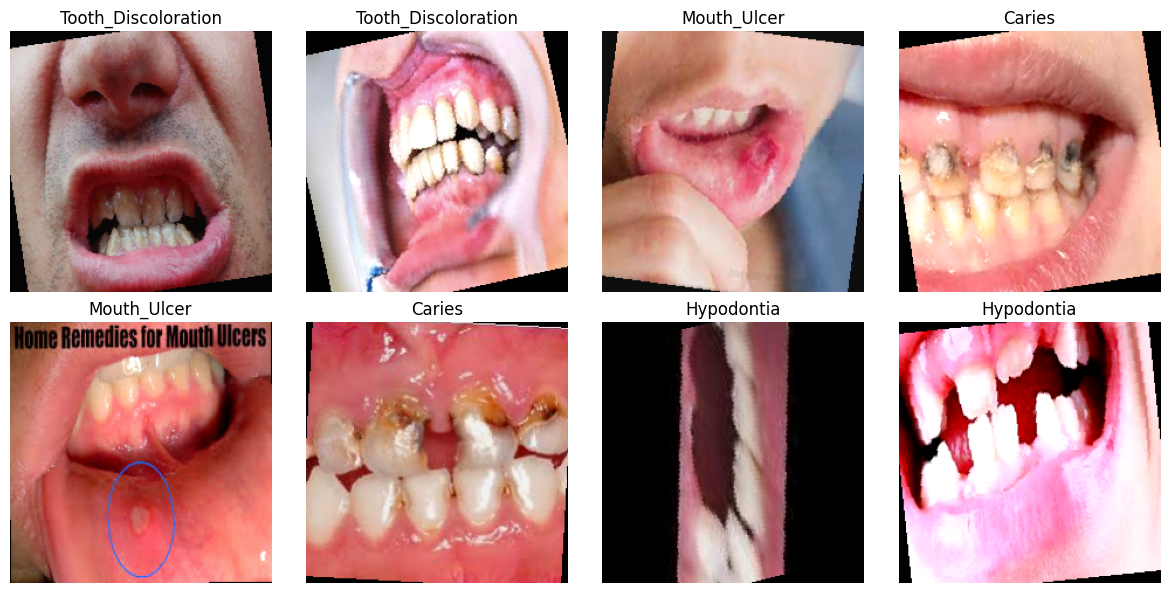

In [54]:
# ============================================
# Display Sample Batch
# ============================================

# Get one batch
images, labels = next(iter(train_loader))

# Undo normalization for visualization
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std = torch.tensor(IMAGENET_STD).view(3,1,1)

fig, axes = plt.subplots(2,4, figsize=(12,6))

axes = axes.flatten()

# Get class names
class_names = sorted(train_df["label"].unique())

for i in range(8):

    img = images[i] * std + mean
    img = img.permute(1,2,0).numpy()

    axes[i].imshow(np.clip(img,0,1))
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# 10. Custom CNN Model

A custom Convolutional Neural Network (CNN) is designed from scratch
to classify oral disease images.

The architecture consists of three convolutional blocks followed by
Batch Normalization, ReLU activation, MaxPooling, Dropout, and fully
connected layers.

Xavier weight initialization is applied to improve convergence during
training.

In [55]:
# ============================================
# Custom CNN Architecture
# ============================================

class CustomCNN(nn.Module):
    """
    Custom CNN for Oral Disease Classification.
    """

    def __init__(self, num_classes):

        super(CustomCNN, self).__init__()

        # -------- Block 1 --------
        self.block1 = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2)

        )

        # -------- Block 2 --------
        self.block2 = nn.Sequential(

            nn.Conv2d(32,64,3,padding=1),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)

        )

        # -------- Block 3 --------
        self.block3 = nn.Sequential(

            nn.Conv2d(64,128,3,padding=1),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)

        )

        # Adaptive pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        # Classifier
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(128,64),

            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(64,num_classes)

        )

        # Initialize weights
        self._initialize_weights()

    def forward(self,x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.avgpool(x)

        x = self.classifier(x)

        return x


    def _initialize_weights(self):
        """
        Xavier Initialization
        """

        for m in self.modules():

            if isinstance(m,nn.Conv2d):

                nn.init.xavier_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m,nn.Linear):

                nn.init.xavier_uniform_(m.weight)

                nn.init.zeros_(m.bias)

In [56]:
# ============================================
# Build Model
# ============================================

model = CustomCNN(NUM_CLASSES).to(device)

print(model)

CustomCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequentia

In [57]:
# ============================================
# Count Trainable Parameters
# ============================================

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable Parameters : {trainable_params:,}")

Trainable Parameters : 102,342


In [58]:
# ============================================
# Test Model
# ============================================

dummy = torch.randn(2,3,224,224).to(device)

output = model(dummy)

print("Output Shape :",output.shape)

Output Shape : torch.Size([2, 6])


In [59]:
# ============================================
# Compute Class Weights
# ============================================

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training labels
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

# Convert to PyTorch tensor
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class Weights:")
print(class_weights)

Class Weights:
tensor([0.7155, 4.2418, 0.3948, 0.7409, 3.4892, 5.0703], device='cuda:0')


In [77]:
# ============================================
# Optimizer and Scheduler
# ============================================

LEARNING_RATE = 1e-3
EPOCHS = 30

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [80]:
# ============================================
# Training History
# ============================================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# 11. Training Pipeline

This section defines reusable training and validation functions.

The same pipeline will be used to train the Custom CNN,
ResNet50, EfficientNet-B0, and MobileNetV3 to ensure
a fair comparison between all models.

In [81]:
# ============================================
# Train One Epoch
# ============================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """

    # Set model to training mode
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar
    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for images, labels in progress_bar:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item() * images.size(0)

        # Predictions
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        progress_bar.set_postfix(
            Loss=loss.item(),
            Accuracy=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [82]:
# ============================================
# Validate One Epoch
# ============================================

def validate_one_epoch(model, dataloader, criterion, device):
    """
    Evaluate the model on the validation set.
    """

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# 12. Model Training Function

A reusable training function is implemented to train different deep
learning models using the same training pipeline.

The function includes:

- Training and validation loops
- Learning rate scheduling
- Early stopping
- Saving the best model
- Recording training history

In [83]:
# ============================================
# Early Stopping
# ============================================

class EarlyStopping:
    """
    Stop training when validation loss stops improving.
    """

    def __init__(self, patience=5):

        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True

In [84]:
# ============================================
# Train Model
# ============================================

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs,
    model_name
):
    """
    Train a deep learning model.
    """

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_accuracy = 0.0

    early_stopping = EarlyStopping(patience=5)

    save_path = MODEL_DIR / f"{model_name}.pth"

    for epoch in range(epochs):

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print("-" * 40)

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.4f}")

        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.4f}")

        # Save best model
        if val_acc > best_accuracy:

            best_accuracy = val_acc

            torch.save(model.state_dict(), save_path)

            print("Best model saved.")

        # Early stopping
        early_stopping(val_loss)

        if early_stopping.early_stop:

            print("\nEarly stopping triggered.")
            break

    print(f"\nBest Validation Accuracy : {best_accuracy:.4f}")

    return history

In [85]:
# ============================================
# Train Custom CNN
# ============================================

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    model_name="custom_cnn"
)


Epoch [1/30]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 1.2870
Train Acc  : 0.4869
Val Loss   : 1.2945
Val Acc    : 0.4341
Best model saved.

Epoch [2/30]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 1.2107
Train Acc  : 0.5064
Val Loss   : 1.3888
Val Acc    : 0.2950

Epoch [3/30]
----------------------------------------


...

Train Loss : 0.9670
Train Acc  : 0.6243
Val Loss   : 0.9059
Val Acc    : 0.6031

Epoch [23/30]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.9651
Train Acc  : 0.6235
Val Loss   : 0.9728
Val Acc    : 0.5803

Epoch [24/30]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.9521
Train Acc  : 0.6248
Val Loss   : 0.9055
Val Acc    : 0.6055

Early stopping triggered.

Best Validation Accuracy : 0.6307


In [86]:
# ============================================
# Evaluation Libraries
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [87]:
# ============================================
# Evaluate Model
# ============================================

def evaluate_model(model, dataloader, device):
    """
    Evaluate a trained model on the test dataset.

    Returns:
        dict: Dictionary containing evaluation metrics.
    """

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in dataloader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Predicted class
            predictions = torch.argmax(outputs, dim=1)

            # Store results
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    # Calculate evaluation metrics
    accuracy = accuracy_score(all_labels, all_predictions)

    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    # Print results
    print("=" * 50)
    print("Evaluation Results")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")

    print(classification_report(
        all_labels,
        all_predictions,
        target_names=sorted(train_df["label"].unique()),
        zero_division=0
    ))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_predictions
    }

In [88]:
# ============================================
# Load Best Model
# ============================================

model.load_state_dict(
    torch.load(
        MODEL_DIR / "custom_cnn.pth",
        map_location=device
    )
)

results_custom = evaluate_model(
    model,
    test_loader,
    device
)

plot_confusion_matrix(results_custom)

Evaluation Results
Accuracy : 0.6144
Precision: 0.7099
Recall   : 0.6144
F1 Score : 0.6312

Classification Report

                     precision    recall  f1-score   support

           Calculus       0.48      0.78      0.60       195
             Caries       0.20      0.42      0.27        33
         Gingivitis       0.81      0.49      0.61       353
         Hypodontia       0.92      0.71      0.80       188
        Mouth_Ulcer       0.67      0.72      0.69        39
Tooth_Discoloration       0.27      0.52      0.36        27

           accuracy                           0.61       835
          macro avg       0.56      0.61      0.55       835
       weighted avg       0.71      0.61      0.63       835



NameError: name 'plot_confusion_matrix' is not defined

In [90]:
# ============================================
# Store Model Results
# ============================================

model_results = {}

model_results["Custom CNN"] = {
    "Accuracy": results_custom["accuracy"],
    "Precision": results_custom["precision"],
    "Recall": results_custom["recall"],
    "F1-Score": results_custom["f1"]
}

In [93]:
# ============================================
# Plot Confusion Matrix
# ============================================

def plot_confusion_matrix(results, model_name=None):
    """
    Plot and optionally save the confusion matrix.
    """

    cm = confusion_matrix(
        results["labels"],
        results["predictions"]
    )

    fig, ax = plt.subplots(figsize=(8, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(train_df["label"].unique())
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d"
    )

    ax.set_title("Confusion Matrix")
    plt.xticks(rotation=30)

    # Save figure if model name is provided
    if model_name is not None:
        plt.savefig(
            RESULTS_DIR / f"{model_name}_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

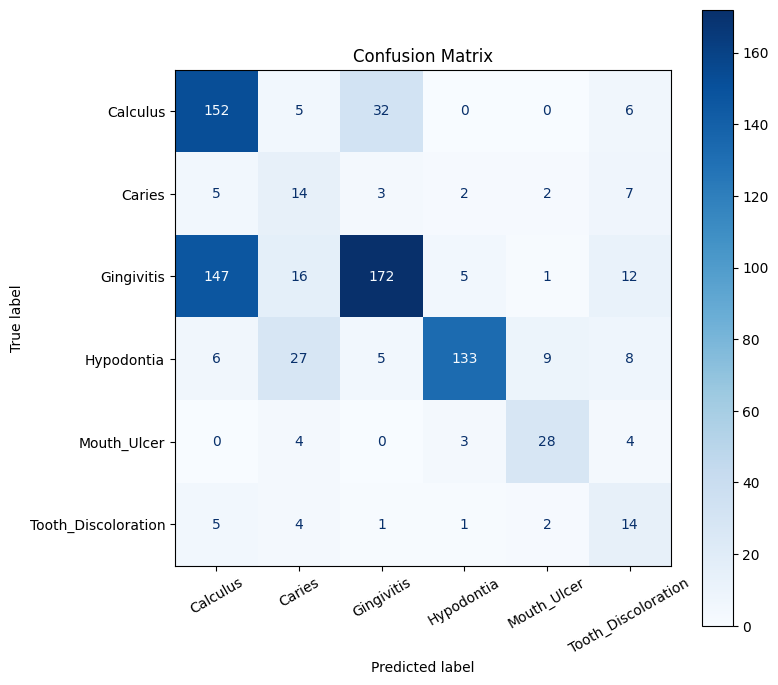

In [94]:
plot_confusion_matrix(
    results_custom,
    model_name="custom_cnn"
)

# 14. Training Curves

The training and validation curves are plotted to monitor the learning
process and detect overfitting or underfitting.

The figures are also saved for use in the final report.

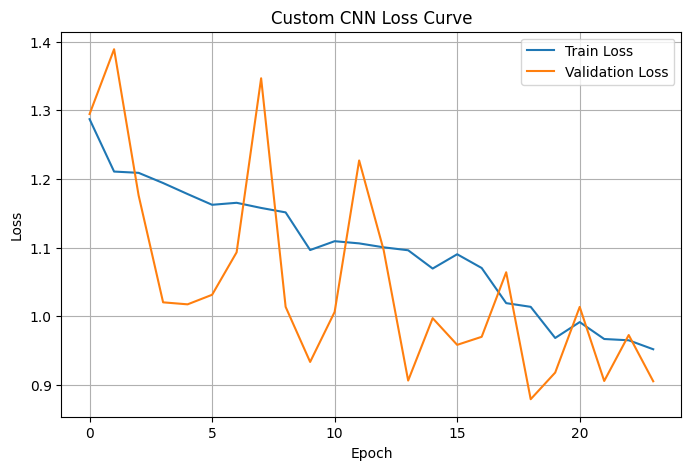

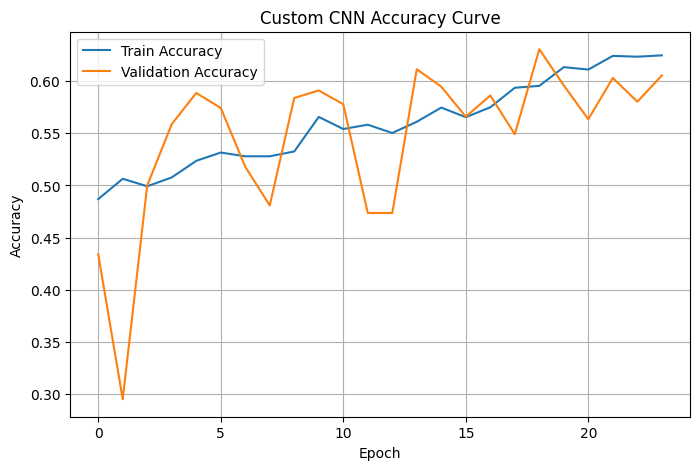

In [95]:
# ============================================
# Plot Training Curves
# ============================================

# Loss Curve
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    RESULTS_DIR / "custom_cnn_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("Custom CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    RESULTS_DIR / "custom_cnn_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15. Transfer Learning using ResNet50

In this section, a pretrained ResNet50 model is used for oral disease classification.

The pretrained ImageNet weights are utilized to leverage learned visual
features, while the final classification layer is replaced with a new layer
for the six oral disease classes.

Initially, the backbone is frozen and only the classifier is trained.

In [98]:
# ============================================
# Import ResNet50
# ============================================

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

In [99]:
# ============================================
# Build ResNet50
# ============================================

# Load pretrained ImageNet weights
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier
num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Dropout(0.3),

    nn.Linear(
        num_features,
        NUM_CLASSES
    )

)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [100]:
# ============================================
# Loss Function
# ============================================

criterion = nn.CrossEntropyLoss()


# ============================================
# Optimizer
# ============================================

optimizer = optim.AdamW(

    model.fc.parameters(),

    lr=1e-3,

    weight_decay=1e-4

)


# ============================================
# Learning Rate Scheduler
# ============================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3

)

In [101]:
# ============================================
# Train ResNet50
# ============================================

history_resnet = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    epochs=15,

    model_name="resnet50"

)


Epoch [1/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 1.3275
Train Acc  : 0.5696
Val Loss   : 1.2100
Val Acc    : 0.5923
Best model saved.

Epoch [2/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.9851
Train Acc  : 0.6852
Val Loss   : 1.0356
Val Acc    : 0.6319
Best model saved.

Epoch [3/15]
----------------------------------------


...

Train Loss : 0.5189
Train Acc  : 0.8192
Val Loss   : 0.6742
Val Acc    : 0.7614
Best model saved.

Epoch [14/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.5224
Train Acc  : 0.8174
Val Loss   : 0.6946
Val Acc    : 0.7422

Epoch [15/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.5218
Train Acc  : 0.8187
Val Loss   : 0.7047
Val Acc    : 0.7374

Best Validation Accuracy : 0.7614


In [102]:
# ============================================
# Fine-Tune ResNet50
# ============================================

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True

In [104]:
optimizer = optim.AdamW(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=1e-4,

    weight_decay=1e-4

)

In [105]:
history_resnet_ft = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    epochs=10,

    model_name="resnet50_finetuned"

)


Epoch [1/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.3847
Train Acc  : 0.8582
Val Loss   : 0.4875
Val Acc    : 0.8106
Best model saved.

Epoch [2/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.2857
Train Acc  : 0.8865
Val Loss   : 0.4577
Val Acc    : 0.8094

Epoch [3/10]
----------------------------------------


...

Train Loss : 0.1504
Train Acc  : 0.9350
Val Loss   : 0.3698
Val Acc    : 0.8501

Epoch [9/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.1536
Train Acc  : 0.9330
Val Loss   : 0.3861
Val Acc    : 0.8441

Epoch [10/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.1595
Train Acc  : 0.9309
Val Loss   : 0.3744
Val Acc    : 0.8477

Best Validation Accuracy : 0.8597


Evaluation Results
Accuracy : 0.8323
Precision: 0.8428
Recall   : 0.8323
F1 Score : 0.8337

Classification Report

                     precision    recall  f1-score   support

           Calculus       0.68      0.80      0.74       195
             Caries       0.69      0.67      0.68        33
         Gingivitis       0.90      0.77      0.83       353
         Hypodontia       0.94      0.99      0.96       188
        Mouth_Ulcer       0.97      0.92      0.95        39
Tooth_Discoloration       0.66      0.85      0.74        27

           accuracy                           0.83       835
          macro avg       0.81      0.83      0.82       835
       weighted avg       0.84      0.83      0.83       835



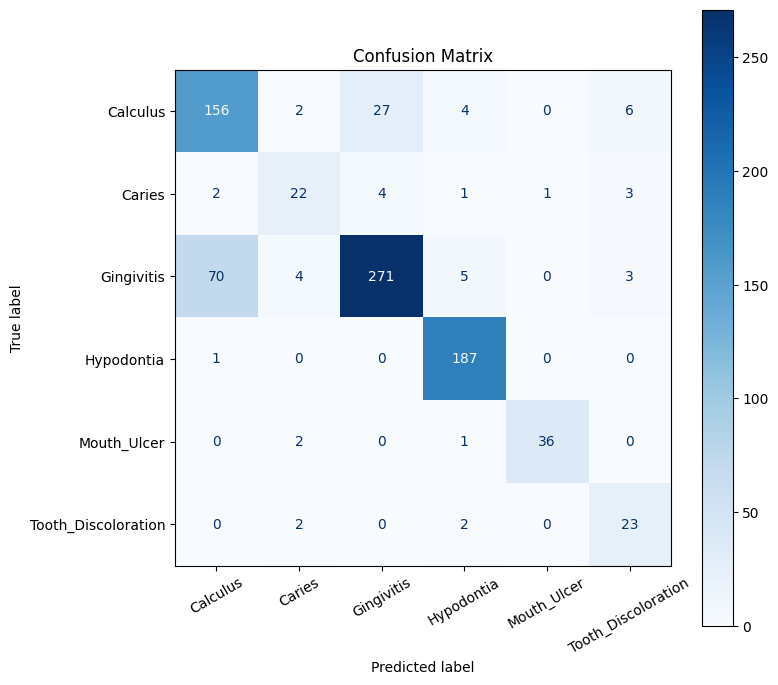

In [106]:
# ============================================
# Evaluate Fine-Tuned ResNet50
# ============================================

model.load_state_dict(
    torch.load(
        MODEL_DIR / "resnet50_finetuned.pth",
        map_location=device
    )
)

results_resnet = evaluate_model(
    model,
    test_loader,
    device
)

plot_confusion_matrix(
    results_resnet,
    model_name="resnet50_finetuned"
)

In [108]:
model_results["ResNet50 (Fine-Tuned)"] = {
    "Accuracy": results_resnet["accuracy"],
    "Precision": results_resnet["precision"],
    "Recall": results_resnet["recall"],
    "F1-Score": results_resnet["f1"]
}

# 16. Transfer Learning using EfficientNet-B0

In this section, EfficientNet-B0 is used as a pretrained model for oral
disease image classification.

EfficientNet achieves high accuracy with fewer parameters by balancing
network depth, width, and input resolution.

The model is first trained using feature extraction by freezing the
backbone, followed by fine-tuning.

In [112]:
# ============================================
# Import EfficientNet-B0
# ============================================

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

In [113]:
# ============================================
# Build EfficientNet-B0
# ============================================

# Load pretrained ImageNet weights
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Number of input features
num_features = model.classifier[1].in_features

# Replace classifier
model.classifier = nn.Sequential(

    nn.Dropout(0.3),

    nn.Linear(
        num_features,
        NUM_CLASSES
    )

)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [114]:
# ============================================
# Loss Function
# ============================================

criterion = nn.CrossEntropyLoss()


# ============================================
# Optimizer
# ============================================

optimizer = optim.AdamW(

    model.classifier.parameters(),

    lr=1e-3,

    weight_decay=1e-4

)


# ============================================
# Scheduler
# ============================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3

)

In [115]:
# ============================================
# Train EfficientNet-B0
# ============================================

history_efficientnet = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    epochs=15,

    model_name="efficientnet_b0"

)


Epoch [1/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 1.2615
Train Acc  : 0.5637
Val Loss   : 0.9777
Val Acc    : 0.6655
Best model saved.

Epoch [2/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.9290
Train Acc  : 0.6864
Val Loss   : 0.8380
Val Acc    : 0.6811
Best model saved.

Epoch [3/15]
----------------------------------------


...

Train Loss : 0.6663
Train Acc  : 0.7625
Val Loss   : 0.7838
Val Acc    : 0.6787

Epoch [11/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.6740
Train Acc  : 0.7504
Val Loss   : 0.7377
Val Acc    : 0.6906

Epoch [12/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.6405
Train Acc  : 0.7655
Val Loss   : 0.7135
Val Acc    : 0.7098

Early stopping triggered.

Best Validation Accuracy : 0.7218


In [116]:
# ============================================
# Fine-Tune EfficientNet-B0
# ============================================

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last feature block
for param in model.features[-1].parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [118]:
# ============================================
# Optimizer for Fine-Tuning
# ============================================

optimizer = optim.AdamW(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=1e-4,

    weight_decay=1e-4

)

In [119]:
# ============================================
# Fine-Tune EfficientNet-B0
# ============================================

history_efficientnet_ft = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    epochs=10,

    model_name="efficientnet_b0_finetuned"

)


Epoch [1/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.6409
Train Acc  : 0.7607
Val Loss   : 0.6825
Val Acc    : 0.7230
Best model saved.

Epoch [2/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.5688
Train Acc  : 0.7886
Val Loss   : 0.6697
Val Acc    : 0.7290
Best model saved.

Epoch [3/10]
----------------------------------------


...

Train Loss : 0.4591
Train Acc  : 0.8395
Val Loss   : 0.5684
Val Acc    : 0.7686
Best model saved.

Epoch [9/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.4495
Train Acc  : 0.8341
Val Loss   : 0.5771
Val Acc    : 0.7662

Epoch [10/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.4353
Train Acc  : 0.8377
Val Loss   : 0.5661
Val Acc    : 0.7590

Best Validation Accuracy : 0.7686


In [126]:
# ============================================
# Load Best EfficientNet Model
# ============================================

model.load_state_dict(
    torch.load(
        MODEL_DIR / "efficientnet_b0_finetuned.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [128]:
# ============================================
# Evaluate EfficientNet
# ============================================

results_efficientnet = evaluate_model(
    model,
    test_loader,
    device
)

Evaluation Results
Accuracy : 0.7844
Precision: 0.7982
Recall   : 0.7844
F1 Score : 0.7876

Classification Report

                     precision    recall  f1-score   support

           Calculus       0.66      0.79      0.72       195
             Caries       0.47      0.58      0.52        33
         Gingivitis       0.85      0.74      0.79       353
         Hypodontia       0.93      0.89      0.91       188
        Mouth_Ulcer       0.79      0.95      0.86        39
Tooth_Discoloration       0.59      0.63      0.61        27

           accuracy                           0.78       835
          macro avg       0.72      0.76      0.73       835
       weighted avg       0.80      0.78      0.79       835



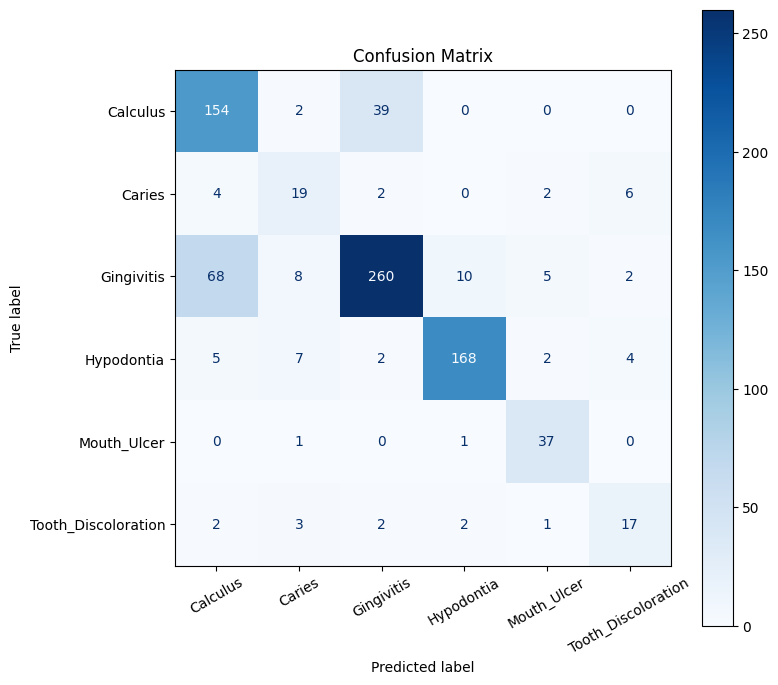

In [129]:
plot_confusion_matrix(
    results_efficientnet,
    model_name="efficientnet_b0_finetuned"
)

In [130]:
model_results["EfficientNet-B0 (Fine-Tuned)"] = {
    "Accuracy": results_efficientnet["accuracy"],
    "Precision": results_efficientnet["precision"],
    "Recall": results_efficientnet["recall"],
    "F1-Score": results_efficientnet["f1"]
}

# 18. Model Comparison

The performance of all trained models is compared using the evaluation
metrics obtained from the test dataset.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-Score

This comparison helps identify the best-performing model for deployment.

In [132]:
# ============================================
# Model Comparison Table
# ============================================

import pandas as pd

comparison_df = pd.DataFrame(model_results).T

comparison_df = comparison_df.round(4)

comparison_df

,Accuracy,Precision,Recall,F1-Score
Custom CNN,0.6144,0.7099,0.6144,0.6312
ResNet50 (Fine-Tuned),0.8323,0.8428,0.8323,0.8337
EfficientNet-B0 (Fine-Tuned),0.7844,0.7982,0.7844,0.7876


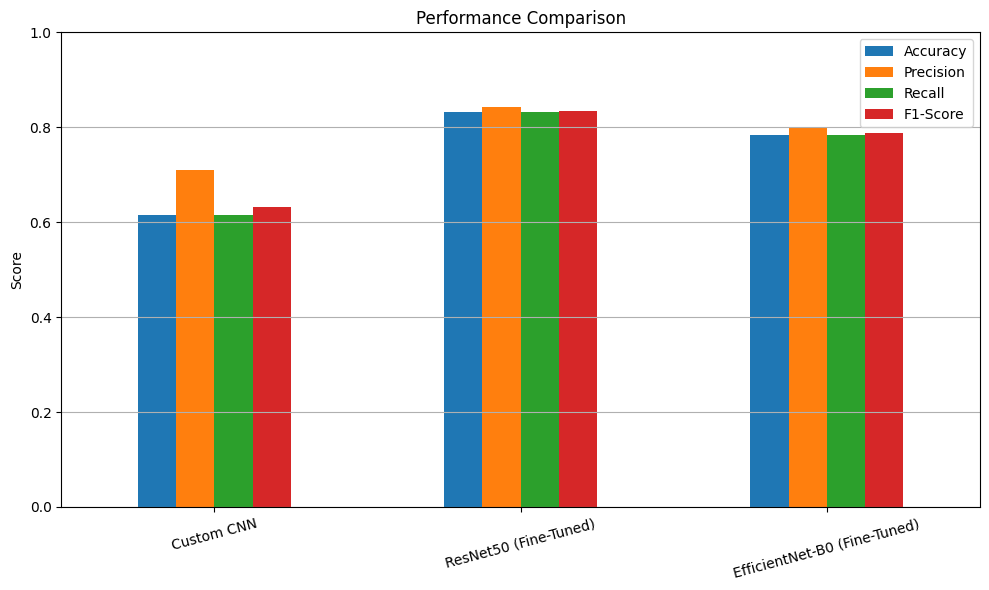

In [133]:
# ============================================
# All Metrics Comparison
# ============================================

comparison_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison")

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis="y")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 18. Transfer Learning using MobileNetV3-Large

In this section, MobileNetV3-Large is employed as the third pretrained
deep learning model for oral disease image classification.

MobileNetV3 is designed to achieve a good balance between accuracy,
computational efficiency, and inference speed, making it suitable for
real-time deployment on edge and mobile devices.

The model is first trained using feature extraction, followed by
fine-tuning of the final feature block.

In [136]:
# ============================================
# Import MobileNetV3
# ============================================

from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)

In [137]:
# ============================================
# Build MobileNetV3-Large
# ============================================

weights = MobileNet_V3_Large_Weights.DEFAULT

model = mobilenet_v3_large(weights=weights)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model.classifier[-1].in_features

model.classifier[-1] = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 120MB/s] 


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [138]:
# ============================================
# Loss Function
# ============================================

criterion = nn.CrossEntropyLoss()

# ============================================
# Optimizer
# ============================================

optimizer = optim.AdamW(

    model.classifier.parameters(),

    lr=1e-3,

    weight_decay=1e-4

)

# ============================================
# Scheduler
# ============================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3

)

In [139]:
# ============================================
# Train MobileNetV3
# ============================================

history_mobilenet = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    epochs=15,

    model_name="mobilenet_v3"

)


Epoch [1/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 1.2429
Train Acc  : 0.6091
Val Loss   : 0.8603
Val Acc    : 0.6942
Best model saved.

Epoch [2/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.8519
Train Acc  : 0.7262
Val Loss   : 0.7638
Val Acc    : 0.7386
Best model saved.

Epoch [3/15]
----------------------------------------


...

Train Loss : 0.5189
Train Acc  : 0.8084
Val Loss   : 0.6073
Val Acc    : 0.7722
Best model saved.

Epoch [14/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.4899
Train Acc  : 0.8267
Val Loss   : 0.6134
Val Acc    : 0.7734
Best model saved.

Epoch [15/15]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.4944
Train Acc  : 0.8187
Val Loss   : 0.6340
Val Acc    : 0.7602

Best Validation Accuracy : 0.7734


# 19. Fine-Tuning MobileNetV3

The last feature block is unfrozen while keeping the remaining backbone
layers frozen.

A lower learning rate is used to adapt the pretrained model without
destroying the learned ImageNet features.

In [140]:
# ============================================
# Fine-Tuning MobileNetV3
# ============================================

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last feature block
for param in model.features[-1].parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print("Fine-Tuning Ready.")

Fine-Tuning Ready.


In [141]:
# ============================================
# Optimizer for Fine-Tuning
# ============================================

optimizer = optim.AdamW(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=1e-4,

    weight_decay=1e-4

)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3

)

In [142]:
# ============================================
# Fine-Tune MobileNetV3
# ============================================

history_mobilenet_ft = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    epochs=10,

    model_name="mobilenet_v3_finetuned"

)


Epoch [1/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.4868
Train Acc  : 0.8274
Val Loss   : 0.5912
Val Acc    : 0.7686
Best model saved.

Epoch [2/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.4316
Train Acc  : 0.8392
Val Loss   : 0.5598
Val Acc    : 0.7854
Best model saved.

Epoch [3/10]
----------------------------------------


...

Train Loss : 0.3112
Train Acc  : 0.8742
Val Loss   : 0.4686
Val Acc    : 0.8094
Best model saved.

Epoch [9/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.2725
Train Acc  : 0.8942
Val Loss   : 0.5378
Val Acc    : 0.7902

Epoch [10/10]
----------------------------------------


Training:   0%|          | 0/122 [00:00<?, ?it/s]

Train Loss : 0.2963
Train Acc  : 0.8847
Val Loss   : 0.4689
Val Acc    : 0.8129
Best model saved.

Best Validation Accuracy : 0.8129


Evaluation Results
Accuracy : 0.8036
Precision: 0.8139
Recall   : 0.8036
F1 Score : 0.8060

Classification Report

                     precision    recall  f1-score   support

           Calculus       0.66      0.74      0.70       195
             Caries       0.56      0.70      0.62        33
         Gingivitis       0.87      0.76      0.81       353
         Hypodontia       0.93      0.95      0.94       188
        Mouth_Ulcer       0.88      0.95      0.91        39
Tooth_Discoloration       0.61      0.74      0.67        27

           accuracy                           0.80       835
          macro avg       0.75      0.81      0.78       835
       weighted avg       0.81      0.80      0.81       835



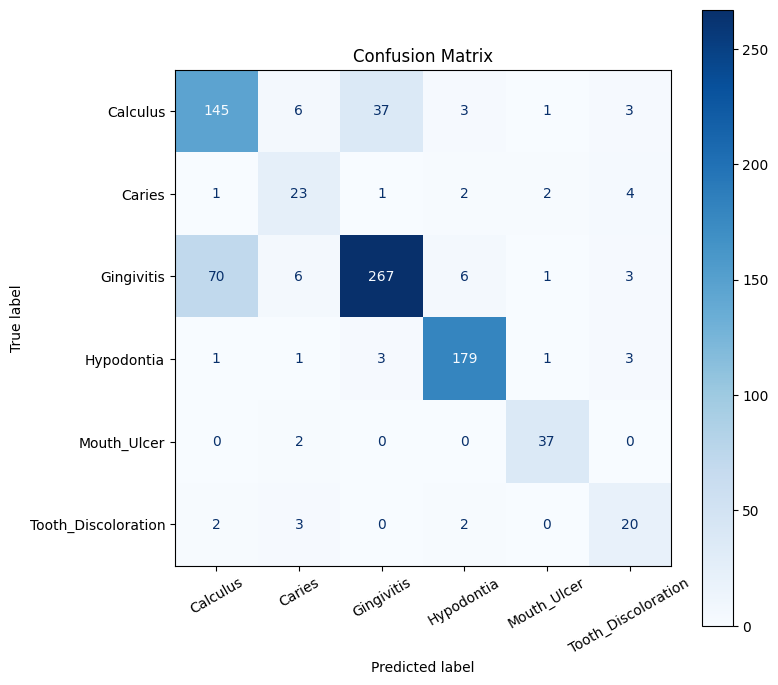

In [143]:
# ============================================
# Evaluate MobileNetV3
# ============================================

model.load_state_dict(

    torch.load(

        MODEL_DIR / "mobilenet_v3_finetuned.pth",

        map_location=device

    )

)

results_mobilenet = evaluate_model(

    model,

    test_loader,

    device

)

plot_confusion_matrix(

    results_mobilenet,

    model_name="mobilenet_v3_finetuned"

)

In [144]:
# ============================================
# Save MobileNetV3 Results
# ============================================

model_results["MobileNetV3 (Fine-Tuned)"] = {

    "Accuracy": results_mobilenet["accuracy"],

    "Precision": results_mobilenet["precision"],

    "Recall": results_mobilenet["recall"],

    "F1-Score": results_mobilenet["f1"]

}

In [145]:
# ============================================
# Final Model Comparison
# ============================================

comparison_df = pd.DataFrame(model_results).T

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df = comparison_df.round(4)

comparison_df

,Accuracy,Precision,Recall,F1-Score
ResNet50 (Fine-Tuned),0.8323,0.8428,0.8323,0.8337
MobileNetV3 (Fine-Tuned),0.8036,0.8139,0.8036,0.8060
EfficientNet-B0 (Fine-Tuned),0.7844,0.7982,0.7844,0.7876
Custom CNN,0.6144,0.7099,0.6144,0.6312


# 20. Performance Analysis

This section summarizes the performance of all implemented models on the
oral diseases classification dataset.

## Model Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|--------|---------:|----------:|-------:|---------:|
| ResNet50 (Fine-Tuned) | **83.23%** | **84.28%** | **83.23%** | **83.37%** |
| MobileNetV3 (Fine-Tuned) | 80.36% | 81.39% | 80.36% | 80.60% |
| EfficientNet-B0 (Fine-Tuned) | 78.44% | 79.82% | 78.44% | 78.76% |
| Custom CNN | 61.44% | 70.99% | 61.44% | 63.12% |

## Discussion

The experimental results show a clear advantage of transfer learning over
training a CNN model from scratch.

The custom CNN achieved acceptable performance and served as a baseline
model. However, its performance was significantly lower than the
pretrained architectures.

Among all evaluated models, **ResNet50 with fine-tuning achieved the best
overall performance**, obtaining the highest Accuracy and F1-Score.
Its residual learning architecture enabled better feature extraction and
generalization on oral disease images.

MobileNetV3 achieved competitive performance while maintaining a much
lighter architecture, making it suitable for applications where inference
speed and computational efficiency are important.

EfficientNet-B0 also produced good results, although its performance was
slightly lower than ResNet50 and MobileNetV3 on this dataset.

Overall, the experiments demonstrate that fine-tuning pretrained CNN
models provides substantial improvements over training a custom CNN from
scratch.

Based on the evaluation metrics, **ResNet50 (Fine-Tuned)** was selected as
the final model for deployment because it achieved the highest overall
classification performance.

In [146]:
import os

print(os.listdir(MODEL_DIR))

['resnet50.pth', 'mobilenet_v3.pth', 'efficientnet_b0_finetuned.pth', 'resnet50_finetuned.pth', 'custom_cnn.pth', 'mobilenet_v3_finetuned.pth', 'efficientnet_b0.pth']


In [151]:
# ============================================
# Get Class Names
# ============================================

import json

# Get unique class names
class_names = sorted(df["label"].unique())

print(class_names)

# Save class names
with open("class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("Class names saved successfully.")

['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Mouth_Ulcer', 'Tooth_Discoloration']
Class names saved successfully.


In [152]:
import os

print(os.getcwd())

/kaggle/working


In [153]:
import os

print(os.listdir("/kaggle/working"))

['class_names.json', 'saved_models', 'dataset_clean', 'results', '.virtual_documents']
